# Week 7 interim: complex model benchmark

**Terry Benjamin Jr.**  
CariSurg MedTech Pathways | 18 July 2026

This notebook adds a Random Forest to the Week 6 emergency-triage benchmark. I kept the
same 80/20 stratified split and random seed so that any change in performance can be
traced to the model and feature work, rather than a different set of test patients.

The interim evidence is organised around the rubric:

- a fitted complex model, plus a training-only tuning pass;
- test-set accuracy, macro precision, macro recall, macro F1 and ESI 1 recall;
- training and per-patient inference timing;
- a draft benchmark table written to `docs/`;
- saved confusion-matrix, comparison and feature-importance artefacts.

## Decisions made before modelling

The target is the recorded Emergency Severity Index (`esi`). As in Week 6, disposition
fields are excluded because they are only known after triage and would leak the outcome.
String fields are held out rather than silently encoded. The two new flags are deliberately
simple and do not use blood pressure:

- `red_flag_hypoxia`: arrival oxygen saturation below 92%;
- `red_flag_tachypnea`: arrival respiratory rate above 20 breaths/min.

I reproduce the tuned Week 6 logistic model on the original feature set, then compare it
with an initial Random Forest and a tuned Random Forest that includes the two flags. The
test set is used once for the final comparison. Hyperparameters are selected using
three-fold cross-validation on the training set only.

In [1]:
from pathlib import Path
from time import perf_counter
import hashlib
import json
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
LABELS = [1, 2, 3, 4, 5]

working_directory = Path.cwd()
repo_root = working_directory.parent if working_directory.name == "notebooks" else working_directory
docs_directory = repo_root / "docs"
docs_directory.mkdir(exist_ok=True)

warnings.filterwarnings("ignore", category=RuntimeWarning)
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": "#333333",
        "axes.labelcolor": "#222222",
        "text.color": "#222222",
        "font.size": 10,
    }
)

print(f"pandas {pd.__version__}")
print(f"numpy {np.__version__}")
print(f"scikit-learn {sklearn.__version__}")
print(f"random seed {RANDOM_STATE}")

pandas 2.3.3
numpy 2.0.2
scikit-learn 1.6.1
random seed 42


## Load and verify the Week 5 triage data

In [2]:
candidate_paths = [
    os.getenv("CARISURG_TRIAGE_CSV"),
    repo_root / "data" / "yaleemmlc_admissionprediction_triage.csv",
    repo_root / "week5" / "data" / "yaleemmlc_admissionprediction_triage.csv",
    working_directory / "yaleemmlc_admissionprediction_triage.csv",
]

data_path = next(
    (Path(path).expanduser() for path in candidate_paths if path and Path(path).expanduser().exists()),
    None,
)
if data_path is None:
    raise FileNotFoundError(
        "Set CARISURG_TRIAGE_CSV to the full Week 5 triage CSV before running this notebook."
    )

triage = pd.read_csv(data_path).drop(columns=["Unnamed: 0"], errors="ignore")

assert triage.shape == (55121, 225)
assert set(triage["esi"].dropna().astype(int).unique()) == set(LABELS)
assert int(triage.duplicated().sum()) == 0
assert int(triage.isna().sum().sum()) == 0

quality_check = pd.DataFrame(
    {
        "check": ["visits", "columns", "missing cells", "duplicate rows"],
        "result": [
            f"{triage.shape[0]:,}",
            triage.shape[1],
            int(triage.isna().sum().sum()),
            int(triage.duplicated().sum()),
        ],
    }
)

print(f"Loaded {triage.shape[0]:,} visits and {triage.shape[1]} columns.")
quality_check

Loaded 55,121 visits and 225 columns.


,check,result
0,visits,"55,121"
1,columns,225
2,missing cells,0
3,duplicate rows,0


## Recreate the Week 6 feature set and held-out split

In [3]:
target = "esi"
leakage_columns = ["disposition", "previousdispo"]
non_numeric_columns = triage.select_dtypes(exclude="number").columns.tolist()
excluded = set([target] + leakage_columns + non_numeric_columns)

base_feature_columns = [
    column
    for column in triage.columns
    if column not in excluded and pd.api.types.is_numeric_dtype(triage[column])
]

X = triage[base_feature_columns].copy()
y = triage[target].astype(int)

assert len(base_feature_columns) == 209
assert X.select_dtypes(exclude="number").empty
assert np.isfinite(X.to_numpy()).all()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

test_index_hash = hashlib.sha256(
    ",".join(map(str, X_test.index)).encode("utf-8")
).hexdigest()
test_class_counts = y_test.value_counts().sort_index()

assert len(X_train) == 44096
assert len(X_test) == 11025
assert test_class_counts.to_dict() == {1: 16, 2: 3585, 3: 5402, 4: 1779, 5: 243}

split_summary = pd.DataFrame(
    {
        "training visits": [len(X_train)],
        "test visits": [len(X_test)],
        "test ESI 1 visits": [int((y_test == 1).sum())],
        "test index SHA-256": [test_index_hash],
    }
)

print("The split matches the Week 6 recipe: test_size=0.20, stratify=y, random_state=42.")
split_summary

The split matches the Week 6 recipe: test_size=0.20, stratify=y, random_state=42.


,training visits,test visits,test ESI 1 visits,test index SHA-256
0,44096,11025,16,5e31ff9f74281290a36280585ecab4a22f5cb2b1ca48a6...


## Add two clinically legible red-flag features

In [4]:
def add_red_flag_features(frame):
    enriched = frame.copy()
    enriched["red_flag_hypoxia"] = (enriched["triage_vital_o2"] < 92).astype(int)
    enriched["red_flag_tachypnea"] = (enriched["triage_vital_rr"] > 20).astype(int)
    return enriched


X_train_enriched = add_red_flag_features(X_train)
X_test_enriched = add_red_flag_features(X_test)

red_flag_summary = pd.DataFrame(
    {
        "training positives": X_train_enriched[
            ["red_flag_hypoxia", "red_flag_tachypnea"]
        ].sum(),
        "test positives": X_test_enriched[
            ["red_flag_hypoxia", "red_flag_tachypnea"]
        ].sum(),
    }
)

assert list(X_train_enriched.columns) == list(X_test_enriched.columns)
assert X_train_enriched.shape[1] == 211
red_flag_summary

,training positives,test positives
red_flag_hypoxia,791,208
red_flag_tachypnea,1888,461


## Evaluation helpers

`train_seconds` covers preprocessing and the final model fit. Hyperparameter search time is
recorded separately because it is a development cost, not the cost of fitting the selected
model once. Inference is warmed once, timed seven times over all 11,025 test visits, then
reported as the median milliseconds per patient.

In [5]:
def esi_one_recall(y_true, y_pred):
    return recall_score(
        y_true,
        y_pred,
        labels=[1],
        average=None,
        zero_division=0,
    )[0]


def timed_fit_and_predict(model, X_fit, y_fit, X_holdout, inference_repeats=7):
    fit_start = perf_counter()
    model.fit(X_fit, y_fit)
    train_seconds = perf_counter() - fit_start

    model.predict(X_holdout.iloc[:1])
    inference_runs = []
    predictions = None
    for _ in range(inference_repeats):
        inference_start = perf_counter()
        predictions = model.predict(X_holdout)
        inference_runs.append(perf_counter() - inference_start)

    inference_seconds = float(np.median(inference_runs))
    return model, predictions, train_seconds, inference_seconds * 1000 / len(X_holdout)


def summarise_model(name, y_true, y_pred, train_seconds, inference_ms, interpretability):
    matrix = confusion_matrix(y_true, y_pred, labels=LABELS)
    esi_1_caught = int(matrix[0, 0])
    esi_1_total = int(matrix[0].sum())

    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "macro_recall": recall_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "esi_1_recall": esi_1_caught / esi_1_total,
        "esi_1_caught": esi_1_caught,
        "esi_1_missed": esi_1_total - esi_1_caught,
        "train_seconds": train_seconds,
        "inference_ms_per_patient": inference_ms,
        "interpretability": interpretability,
    }

## Reproduce the tuned Week 6 logistic baseline

In [6]:
logistic_baseline = Pipeline(
    [
        ("scale", StandardScaler()),
        (
            "model",
            LogisticRegression(
                max_iter=1500,
                class_weight={1: 8},
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

(
    logistic_baseline,
    logistic_predictions,
    logistic_train_seconds,
    logistic_inference_ms,
) = timed_fit_and_predict(logistic_baseline, X_train, y_train, X_test)

logistic_result = summarise_model(
    "Week 6 tuned logistic",
    y_test,
    logistic_predictions,
    logistic_train_seconds,
    logistic_inference_ms,
    "High",
)

pd.DataFrame([logistic_result]).set_index("model").style.format(
    {
        "accuracy": "{:.3f}",
        "macro_precision": "{:.3f}",
        "macro_recall": "{:.3f}",
        "macro_f1": "{:.3f}",
        "esi_1_recall": "{:.3f}",
        "train_seconds": "{:.2f}",
        "inference_ms_per_patient": "{:.4f}",
    }
)

,accuracy,macro_precision,macro_recall,macro_f1,esi_1_recall,esi_1_caught,esi_1_missed,train_seconds,inference_ms_per_patient,interpretability
model,,,,,,,,,,
Week 6 tuned logistic,0.681,0.553,0.511,0.501,0.438,7,9,1.70,0.0008,High


## Fit an initial Random Forest

In [7]:
initial_forest = RandomForestClassifier(
    n_estimators=250,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

(
    initial_forest,
    initial_forest_predictions,
    initial_forest_train_seconds,
    initial_forest_inference_ms,
) = timed_fit_and_predict(initial_forest, X_train, y_train, X_test)

initial_forest_result = summarise_model(
    "Initial Random Forest",
    y_test,
    initial_forest_predictions,
    initial_forest_train_seconds,
    initial_forest_inference_ms,
    "Medium",
)

pd.DataFrame([initial_forest_result]).set_index("model").style.format(
    {
        "accuracy": "{:.3f}",
        "macro_precision": "{:.3f}",
        "macro_recall": "{:.3f}",
        "macro_f1": "{:.3f}",
        "esi_1_recall": "{:.3f}",
        "train_seconds": "{:.2f}",
        "inference_ms_per_patient": "{:.4f}",
    }
)

,accuracy,macro_precision,macro_recall,macro_f1,esi_1_recall,esi_1_caught,esi_1_missed,train_seconds,inference_ms_per_patient,interpretability
model,,,,,,,,,,
Initial Random Forest,0.623,0.475,0.548,0.493,0.312,5,11,9.59,0.0184,Medium


## Tune on the training set only

The search scores macro F1 and ESI 1 recall across three stratified folds. Selection starts
with candidates within 0.025 macro-F1 of the strongest candidate, then prefers the best
ESI 1 recall inside that competitive group. This keeps the search from buying a small
average-score gain by ignoring the rarest and most urgent class.

In [8]:
def choose_refit_candidate(results):
    scores = pd.DataFrame(
        {
            "macro_f1": results["mean_test_macro_f1"],
            "esi_1_recall": results["mean_test_esi_1_recall"],
        }
    )
    competitive = scores["macro_f1"] >= scores["macro_f1"].max() - 0.025
    return int(
        scores.loc[competitive]
        .sort_values(["esi_1_recall", "macro_f1"], ascending=False)
        .index[0]
    )


cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "macro_f1": "f1_macro",
    "esi_1_recall": make_scorer(esi_one_recall),
}
class_weight_candidates = [
    "balanced",
    "balanced_subsample",
    {1: 6, 2: 1.5, 3: 1, 4: 1, 5: 1},
    {1: 12, 2: 2, 3: 1, 4: 1, 5: 1},
]
parameter_space = {
    "n_estimators": [200, 300, 450],
    "max_depth": [None, 14, 22],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", 0.4, 0.6],
    "class_weight": class_weight_candidates,
}

search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=parameter_space,
    n_iter=8,
    scoring=scoring,
    refit=choose_refit_candidate,
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=False,
)

search_start = perf_counter()
search.fit(X_train_enriched, y_train)
search_seconds = perf_counter() - search_start

cv_results = pd.DataFrame(search.cv_results_)
cv_summary = (
    cv_results[
        [
            "rank_test_macro_f1",
            "mean_test_macro_f1",
            "mean_test_esi_1_recall",
            "mean_fit_time",
            "params",
        ]
    ]
    .sort_values(["mean_test_macro_f1", "mean_test_esi_1_recall"], ascending=False)
    .reset_index(drop=True)
)
cv_summary.to_csv(docs_directory / "week7_random_forest_cv_results.csv", index=False)

print(f"Search time: {search_seconds:.1f} seconds")
print("Selected parameters:")
print(json.dumps(search.best_params_, indent=2))
cv_summary.head(8).style.format(
    {
        "mean_test_macro_f1": "{:.3f}",
        "mean_test_esi_1_recall": "{:.3f}",
        "mean_fit_time": "{:.2f}",
    }
)

Search time: 305.1 seconds
Selected parameters:
{
  "n_estimators": 200,
  "min_samples_leaf": 4,
  "max_features": 0.6,
  "max_depth": null,
  "class_weight": "balanced"
}


,rank_test_macro_f1,mean_test_macro_f1,mean_test_esi_1_recall,mean_fit_time,params
0,1,0.483,0.229,207.14,"{'n_estimators': 200, 'min_samples_leaf': 4, 'max_features': 0.6, 'max_depth': None, 'class_weight': 'balanced'}"
1,2,0.440,0.197,24.81,"{'n_estimators': 200, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 22, 'class_weight': 'balanced'}"
2,3,0.403,0.017,29.48,"{'n_estimators': 200, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 22, 'class_weight': 'balanced_subsample'}"
3,4,0.393,0.408,17.21,"{'n_estimators': 300, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'max_depth': 14, 'class_weight': 'balanced_subsample'}"
4,5,0.381,0.196,197.63,"{'n_estimators': 300, 'min_samples_leaf': 2, 'max_features': 0.6, 'max_depth': 22, 'class_weight': {1: 12, 2: 2, 3: 1, 4: 1, 5: 1}}"
5,6,0.373,0.163,57.45,"{'n_estimators': 200, 'min_samples_leaf': 4, 'max_features': 0.4, 'max_depth': 22, 'class_weight': {1: 12, 2: 2, 3: 1, 4: 1, 5: 1}}"
6,7,0.332,0.148,193.69,"{'n_estimators': 450, 'min_samples_leaf': 4, 'max_features': 0.6, 'max_depth': 14, 'class_weight': {1: 12, 2: 2, 3: 1, 4: 1, 5: 1}}"
7,8,0.310,0.017,100.63,"{'n_estimators': 450, 'min_samples_leaf': 8, 'max_features': 0.4, 'max_depth': 14, 'class_weight': {1: 6, 2: 1.5, 3: 1, 4: 1, 5: 1}}"


## Refit the selected forests and benchmark the held-out test set

The primary forest follows the competitive macro-F1 rule above. I also retain the
training-fold candidate with the highest ESI 1 recall as a safety-sensitive alternative.
Both choices are made before test-set evaluation.

In [9]:
tuned_forest = RandomForestClassifier(
    **search.best_params_,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

(
    tuned_forest,
    tuned_forest_predictions,
    tuned_forest_train_seconds,
    tuned_forest_inference_ms,
) = timed_fit_and_predict(
    tuned_forest,
    X_train_enriched,
    y_train,
    X_test_enriched,
)

tuned_forest_result = summarise_model(
    "Macro-F1 Random Forest + red flags",
    y_test,
    tuned_forest_predictions,
    tuned_forest_train_seconds,
    tuned_forest_inference_ms,
    "Medium",
)

safety_index = int(cv_results["mean_test_esi_1_recall"].idxmax())
safety_params = cv_results.loc[safety_index, "params"]
safety_forest = RandomForestClassifier(
    **safety_params,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

(
    safety_forest,
    safety_forest_predictions,
    safety_forest_train_seconds,
    safety_forest_inference_ms,
) = timed_fit_and_predict(
    safety_forest,
    X_train_enriched,
    y_train,
    X_test_enriched,
)

safety_forest_result = summarise_model(
    "ESI 1-sensitive Random Forest + red flags",
    y_test,
    safety_forest_predictions,
    safety_forest_train_seconds,
    safety_forest_inference_ms,
    "Medium",
)

benchmark = pd.DataFrame(
    [
        logistic_result,
        initial_forest_result,
        tuned_forest_result,
        safety_forest_result,
    ]
).set_index("model")
benchmark.to_csv(docs_directory / "week7_benchmark_metrics.csv")

benchmark.style.format(
    {
        "accuracy": "{:.3f}",
        "macro_precision": "{:.3f}",
        "macro_recall": "{:.3f}",
        "macro_f1": "{:.3f}",
        "esi_1_recall": "{:.3f}",
        "train_seconds": "{:.2f}",
        "inference_ms_per_patient": "{:.4f}",
    }
)

,accuracy,macro_precision,macro_recall,macro_f1,esi_1_recall,esi_1_caught,esi_1_missed,train_seconds,inference_ms_per_patient,interpretability
model,,,,,,,,,,
Week 6 tuned logistic,0.681,0.553,0.511,0.501,0.438,7,9,1.70,0.0008,High
Initial Random Forest,0.623,0.475,0.548,0.493,0.312,5,11,9.59,0.0184,Medium
Macro-F1 Random Forest + red flags,0.642,0.498,0.509,0.502,0.312,5,11,31.17,0.0108,Medium
ESI 1-sensitive Random Forest + red flags,0.522,0.392,0.545,0.396,0.438,7,9,3.43,0.0060,Medium


The average metrics and the ESI 1 count answer different questions. Macro F1 gives each
class equal weight, while `esi_1_caught` shows what happened to the 16 most urgent visits
in this particular test set. Both are retained in the draft table.

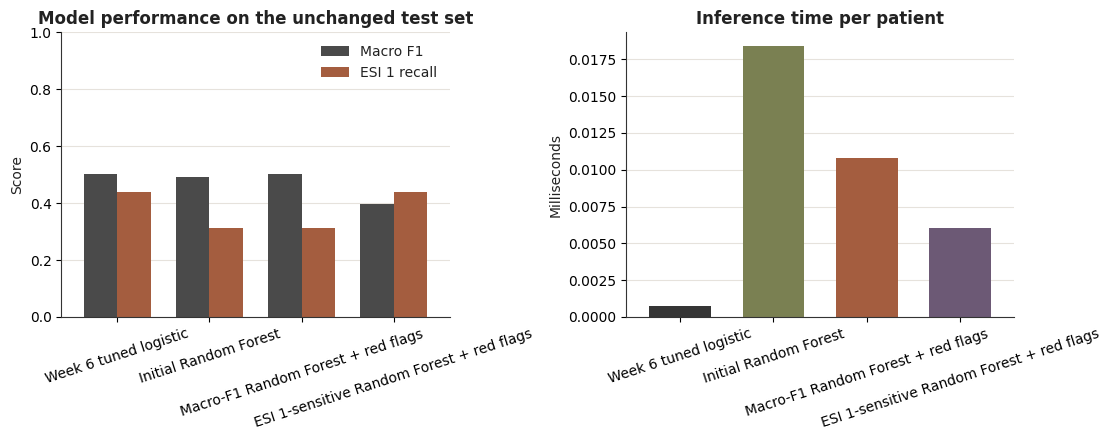

Saved week7_model_comparison.png


In [10]:
palette = ["#353535", "#7A8052", "#A45D3F", "#6C5975"]

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.5))
benchmark[["macro_f1", "esi_1_recall"]].plot(
    kind="bar",
    color=["#4A4A4A", "#A45D3F"],
    width=0.72,
    ax=axes[0],
)
axes[0].set_title("Model performance on the unchanged test set", weight="bold")
axes[0].set_ylabel("Score")
axes[0].set_xlabel("")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=18)
axes[0].legend(["Macro F1", "ESI 1 recall"], frameon=False)

benchmark["inference_ms_per_patient"].plot(
    kind="bar",
    color=palette,
    width=0.66,
    ax=axes[1],
)
axes[1].set_title("Inference time per patient", weight="bold")
axes[1].set_ylabel("Milliseconds")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=18)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#E6E2DC", linewidth=0.8)
    ax.set_axisbelow(True)

fig.tight_layout()
comparison_path = docs_directory / "week7_model_comparison.png"
fig.savefig(comparison_path, dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Saved {comparison_path.name}")

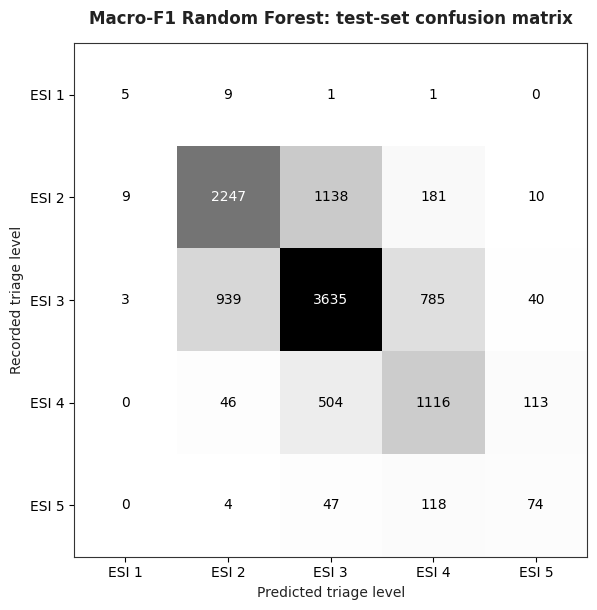

Saved week7_confusion_random_forest.png


In [11]:
fig, ax = plt.subplots(figsize=(7.2, 6.2))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    tuned_forest_predictions,
    labels=LABELS,
    display_labels=[f"ESI {label}" for label in LABELS],
    cmap="Greys",
    colorbar=False,
    ax=ax,
)
ax.set_title("Macro-F1 Random Forest: test-set confusion matrix", pad=14, weight="bold")
ax.set_xlabel("Predicted triage level")
ax.set_ylabel("Recorded triage level")
fig.tight_layout()

confusion_path = docs_directory / "week7_confusion_random_forest.png"
fig.savefig(confusion_path, dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Saved {confusion_path.name}")

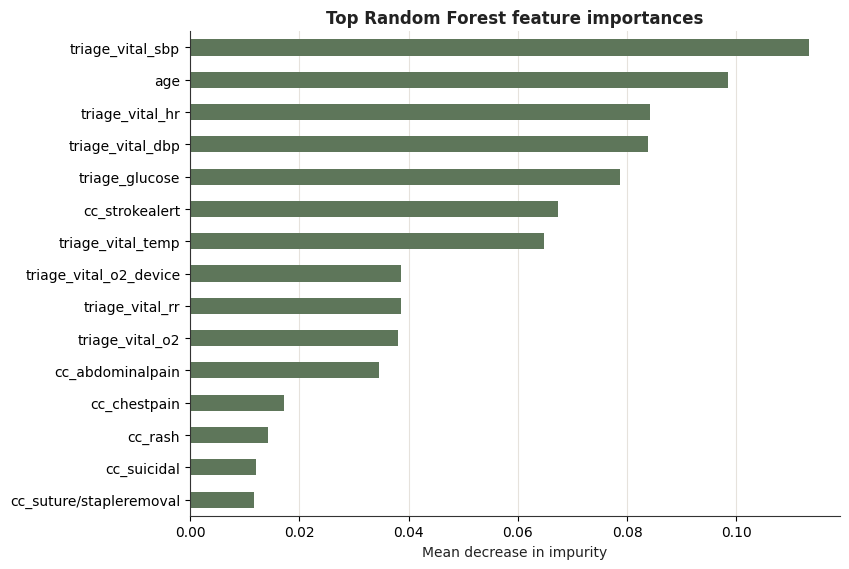

Saved week7_feature_importance.png


In [12]:
importance = (
    pd.Series(
        tuned_forest.feature_importances_,
        index=X_train_enriched.columns,
        name="importance",
    )
    .sort_values(ascending=False)
    .head(15)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(8.6, 5.8))
importance.plot(kind="barh", color="#5E765A", ax=ax)
ax.set_title("Top Random Forest feature importances", weight="bold")
ax.set_xlabel("Mean decrease in impurity")
ax.set_ylabel("")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color="#E6E2DC", linewidth=0.8)
ax.set_axisbelow(True)
fig.tight_layout()

importance_path = docs_directory / "week7_feature_importance.png"
fig.savefig(importance_path, dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

importance.to_csv(docs_directory / "week7_feature_importance.csv", header=True)
print(f"Saved {importance_path.name}")

## ESI 1 check

In [13]:
esi_1_rows = X_test_enriched.loc[y_test == 1].copy()
esi_1_rows["prediction"] = tuned_forest_predictions[(y_test == 1).to_numpy()]
esi_1_rows["outcome"] = np.where(esi_1_rows["prediction"] == 1, "caught", "missed")

esi_1_vital_columns = [
    "age",
    "triage_vital_hr",
    "triage_vital_rr",
    "triage_vital_o2",
    "triage_vital_o2_device",
    "triage_vital_temp",
    "triage_glucose",
    "red_flag_hypoxia",
    "red_flag_tachypnea",
]
esi_1_profile = (
    esi_1_rows.groupby("outcome")[esi_1_vital_columns]
    .median()
    .T
    .rename_axis("measure")
)
esi_1_profile.to_csv(docs_directory / "week7_esi1_vital_profile.csv")

print(esi_1_rows["outcome"].value_counts().to_string())
esi_1_profile.round(2)

outcome
missed    11
caught     5


outcome,caught,missed
measure,,
age,89.0,74.0
triage_vital_hr,69.5,84.0
triage_vital_rr,18.5,18.0
triage_vital_o2,97.0,97.0
triage_vital_o2_device,0.0,0.0
triage_vital_temp,98.0,97.7
triage_glucose,118.0,118.0
red_flag_hypoxia,0.0,0.0
red_flag_tachypnea,0.0,0.0


## Write the draft comparison table to `docs/`

In [14]:
def fmt_score(value):
    return f"{value:.3f}"


table_rows = []
for model_name, row in benchmark.iterrows():
    feature_note = (
        "Week 6 numeric set + 2 red flags"
        if "red flags" in model_name
        else "Week 6 numeric set"
    )
    table_rows.append(
        [
            model_name,
            feature_note,
            fmt_score(row["accuracy"]),
            fmt_score(row["macro_precision"]),
            fmt_score(row["macro_recall"]),
            fmt_score(row["macro_f1"]),
            f'{int(row["esi_1_caught"])}/16 ({row["esi_1_recall"]:.1%})',
            f'{row["train_seconds"]:.2f}',
            f'{row["inference_ms_per_patient"]:.4f}',
            row["interpretability"],
        ]
    )

headers = [
    "Model",
    "Features",
    "Accuracy",
    "Macro precision",
    "Macro recall",
    "Macro F1",
    "ESI 1 caught",
    "Train (s)",
    "Inference (ms/patient)",
    "Interpretability",
]
separator = ["---"] * len(headers)
markdown_table = "\n".join(
    [
        "| " + " | ".join(headers) + " |",
        "| " + " | ".join(separator) + " |",
        *["| " + " | ".join(row) + " |" for row in table_rows],
    ]
)

best_macro_model = benchmark["macro_f1"].idxmax()
best_esi_recall = benchmark["esi_1_recall"].max()
best_esi_models = " and ".join(
    benchmark.index[benchmark["esi_1_recall"] == best_esi_recall].tolist()
)
tuned = benchmark.loc["Macro-F1 Random Forest + red flags"]
safety = benchmark.loc["ESI 1-sensitive Random Forest + red flags"]

draft_text = f'''# Week 7 draft benchmark comparison

**Student:** Terry Benjamin Jr.

**Programme:** CariSurg MedTech Pathways

**Date:** 18 July 2026

## Scope

This draft compares the reproduced Week 6 tuned logistic model with three Week 7
Random Forest runs. All rows use the same stratified holdout created with
`test_size=0.20`, `stratify=y` and `random_state=42`: 44,096 training visits and
11,025 test visits. The test set contains 16 ESI 1 visits. Hyperparameters were
selected by three-fold cross-validation on the training set; the holdout was not
used for selection.

## Initial benchmark

{markdown_table}

The hyperparameter search took {search_seconds:.1f} seconds. This is reported
separately from final-model training time.

## Early read

`{best_macro_model}` has the strongest macro F1 in this first benchmark.
The highest observed ESI 1 recall is {best_esi_recall:.1%}, shared by
{best_esi_models}. The macro-F1 forest caught
{int(tuned["esi_1_caught"])} of 16 ESI 1 visits and missed
{int(tuned["esi_1_missed"])}. The ESI 1-sensitive forest caught
{int(safety["esi_1_caught"])} but gave up substantial macro-F1 performance.
Because that class has only 16 test examples, one
case moves recall by 6.25 percentage points; the count and the rate should stay
together in later reporting.

The Random Forest remains more expensive and less directly interpretable than
logistic regression, although feature importance provides a useful first check.
This interim table is evidence for the Tuesday analysis, not a deployment
recommendation.

## Artefacts

- [Executed Week 7 notebook](../notebooks/week7_interim_complex_model.ipynb)
- [Model comparison plot](week7_model_comparison.png)
- [Random Forest confusion matrix](week7_confusion_random_forest.png)
- [Feature importance plot](week7_feature_importance.png)
- [Machine-readable metrics](week7_benchmark_metrics.csv)
- [Cross-validation results](week7_random_forest_cv_results.csv)
'''

draft_path = docs_directory / "week7_draft_benchmark.md"
draft_path.write_text(draft_text, encoding="utf-8")

print(f"Wrote {draft_path.name}")
print(markdown_table)

Wrote week7_draft_benchmark.md
| Model | Features | Accuracy | Macro precision | Macro recall | Macro F1 | ESI 1 caught | Train (s) | Inference (ms/patient) | Interpretability |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Week 6 tuned logistic | Week 6 numeric set | 0.681 | 0.553 | 0.511 | 0.501 | 7/16 (43.8%) | 1.70 | 0.0008 | High |
| Initial Random Forest | Week 6 numeric set | 0.623 | 0.475 | 0.548 | 0.493 | 5/16 (31.2%) | 9.59 | 0.0184 | Medium |
| Macro-F1 Random Forest + red flags | Week 6 numeric set + 2 red flags | 0.642 | 0.498 | 0.509 | 0.502 | 5/16 (31.2%) | 31.17 | 0.0108 | Medium |
| ESI 1-sensitive Random Forest + red flags | Week 6 numeric set + 2 red flags | 0.522 | 0.392 | 0.545 | 0.396 | 7/16 (43.8%) | 3.43 | 0.0060 | Medium |


## Interim conclusion

This run establishes a traceable Week 7 benchmark without changing the Week 6 test
patients. The next step is not to declare a winner from one aggregate score. The final
analysis needs to examine the remaining ESI 1 misses, compare operational cost against
the accuracy gain, and decide whether the more complex model earns its extra complexity.